# A2.2 LDA y Árboles de Decisión 

En esta actividad trabajarás con la misma base de datos que trabajaste en el proyecto del primer 
parcial y en la actividad A2.1. Si por algún motivo tienes problemas y deseas cambiar de base 
de  datos,  puedes  hacerlo,  especificando  claramente  con  qué  base  de  datos  estás  trabajando ahora y de dónde la obtuviste.  

Desarrolla  los  siguientes  puntos  en  una Jupyter  Notebook,  tratando,  dentro  de  lo  posible,  que cada  punto  se  trabaje  en  una  celda  distinta.  Los  comentarios  en  el  código  siempre  son bienvenidos, de preferencia, aprovecha el markdown para generar cuadros de descripción que ayuden al lector a comprender el trabajo realizado. 

1. Importa los datos a tu ambiente de trabajo y separa los datos en entrenamiento y prueba, con una relación que consideres adecuada, manteniendo un balance de clases. Demuestra que se cumplió la condición imprimiendo datos relevantes en la consola. 

Seguimos utilizando la base de datos con información del los tlacuaches. 

In [15]:
import pandas as pd

df = pd.read_csv("possum.csv")

print("La variable de interés en este caso será el sexo del tlacuache")

# Eliminamos las columnas que no son necesarias como case, site, y Pop
df = df.drop(columns=["case", "site", "Pop"])

# Convertimos la columna sex de m y f a una de Male con 1 y 0
df["male"] = df["sex"].map({"m": 1, "f": 0})
df = df.drop(columns=["sex"])

# Checamos huecos en los datos
df.isnull().sum()
# Eliminamos las filas con datos faltantes ya que son pocos
df = df.dropna()

df.head()

La variable de interés en este caso será el sexo del tlacuache


,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,male
0,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0,1
1,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0,0
2,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0,0
3,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0,0
4,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0,0


Separamos los datos en train y test manteniendo el balance de sexo

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["male"])
y = df["male"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,          # 20%
    stratify=y              # mantiene la proporción
)

# Imprimimos las proporciones de los tres grupos de datos
print("Proporción de clases en los datos originales:")
print(y.value_counts(normalize=True))
print("\nProporción de clases en los datos de entrenamiento:")
print(y_train.value_counts(normalize=True))
print("\nProporción de clases en los datos de prueba:")
print(y_test.value_counts(normalize=True))

Proporción de clases en los datos originales:
male
1    0.584158
0    0.415842
Name: proportion, dtype: float64

Proporción de clases en los datos de entrenamiento:
male
1    0.5875
0    0.4125
Name: proportion, dtype: float64

Proporción de clases en los datos de prueba:
male
1    0.571429
0    0.428571
Name: proportion, dtype: float64


2. Corre  una  regresión  logística  simple con  la  función  GLM  de  statsmodels  con  todas  tus variables de entrada e imprime el resumen del modelo en consola. Indica cuáles son las 2 variables más relevantes para este estudio y selecciónalas, eliminando todas las demás variables de tus datos de entrenamiento y prueba. 

In [18]:
import statsmodels.api as sm

# Agregamos la constante para el modelo
X_train_const = sm.add_constant(X_train)

# Ajustamos el modelo GLM (familia binomial para regresión logística)
glm_model = sm.GLM(y_train, X_train_const, family=sm.families.Binomial())
glm_results = glm_model.fit()

# Imprimimos el resumen del modelo
print(glm_results.summary())

# Seleccionamos las 2 variables más relevantes (con menor p-valor)
relevant_vars = glm_results.pvalues.drop('const').sort_values().index[:2].tolist()
print(f"Variables más relevantes: {relevant_vars}")

# Filtramos los datos de entrenamiento y prueba para solo esas variables
X_train_selected = X_train[relevant_vars]
X_test_selected = X_test[relevant_vars]

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   male   No. Observations:                   80
Model:                            GLM   Df Residuals:                       69
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -48.882
Date:                Wed, 01 Oct 2025   Deviance:                       97.764
Time:                        21:33:43   Pearson chi2:                     79.0
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1249
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.7149      9.228     -1.053      0.2

3. Genera  un  modelo  usando  la  metodología de  linear  discriminant  analysis.  Visualiza  la función discriminante con una gráfica de variable 1 vs variable 2, donde cada observación tenga algo que la distinga dependiendo de su clase (por ejemplo, distinto color, distinto marcador, etc.) 

c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


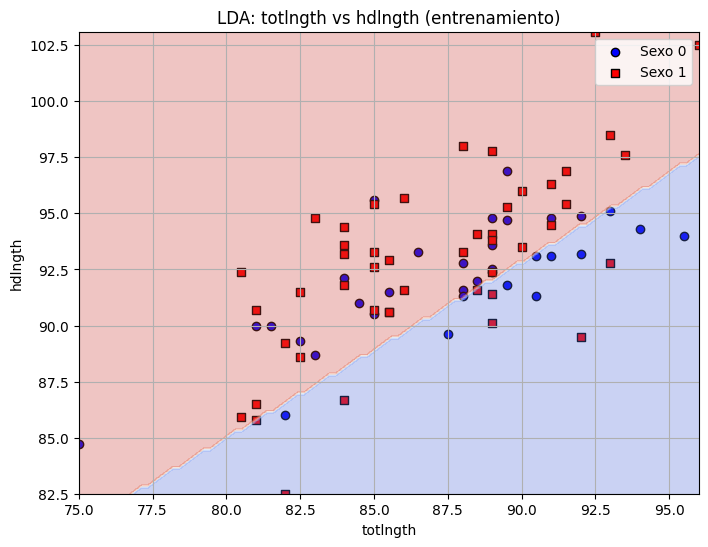

In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
import matplotlib.pyplot as plt

# Entrenamos el modelo LDA con las dos variables seleccionadas
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_selected, y_train)

# Proyectamos los datos de entrenamiento en el espacio discriminante
X_train_proj = lda.transform(X_train_selected)

# Graficamos las observaciones en el espacio original (variable 1 vs variable 2)
plt.figure(figsize=(8,6))
for clase, color, marker in zip([0, 1], ['blue', 'red'], ['o', 's']):
    plt.scatter(
        X_train_selected[y_train == clase]['totlngth'],
        X_train_selected[y_train == clase]['hdlngth'],
        c=color, label=f'Sexo {clase}', marker=marker, edgecolor='k'
    )

# Graficamos la línea de decisión
x_min, x_max = X_train_selected['totlngth'].min(), X_train_selected['totlngth'].max()
y_min, y_max = X_train_selected['hdlngth'].min(), X_train_selected['hdlngth'].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])

plt.contourf(xx, yy, Z.reshape(xx.shape), alpha=0.3, cmap='coolwarm')
plt.xlabel('totlngth')
plt.ylabel('hdlngth')
plt.title('LDA: totlngth vs hdlngth (entrenamiento)')
plt.legend()
plt.grid(True)
plt.show()

4. Genera un modelo usando la metodología de árboles de decisión. Deberás podar el árbol, 
habiendo  seleccionado  primero  un  valor  óptimo  de  𝛼𝛼  mediante  una  metodología  de LOOCV. Visualiza tanto el árbol resultante, como la partición en una gráfica de variable 1 vs  variable  2,  donde  cada  observación  tenga  algo  que  la  distinga  dependiendo  de  su clase. 

Mejor valor de alpha (ccp_alpha) por LOOCV: 0.0367


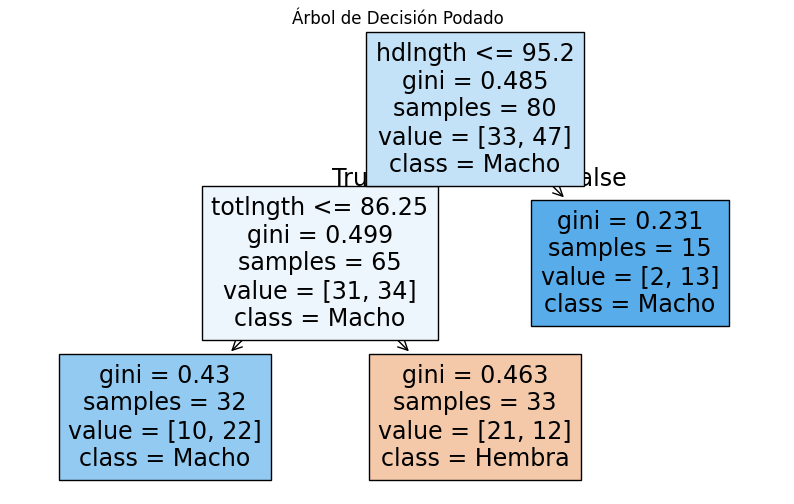

c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


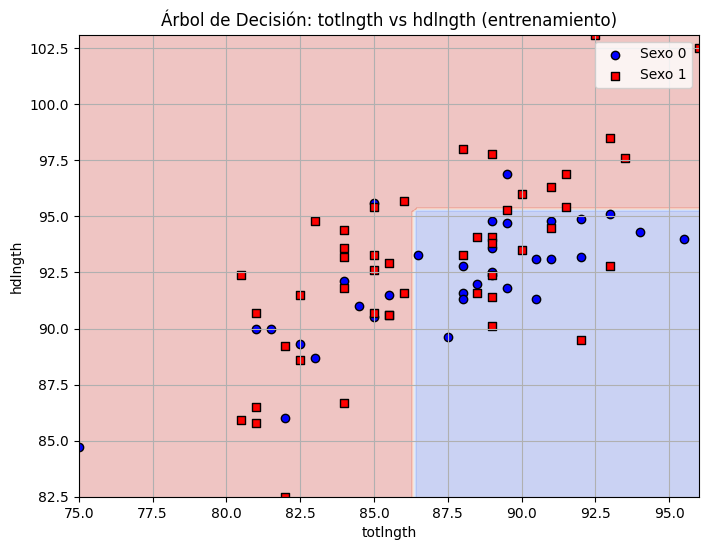

In [22]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import LeaveOneOut, cross_val_score
import numpy as np

import matplotlib.pyplot as plt

# Generamos una lista de posibles valores de alpha para la poda
ccp_alphas = np.linspace(0, 0.05, 50)

# Usamos LOOCV para seleccionar el mejor alpha
loo = LeaveOneOut()
scores = []
for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    cv_score = cross_val_score(tree, X_train_selected, y_train, cv=loo, scoring='accuracy').mean()
    scores.append(cv_score)

# Seleccionamos el alpha con mayor score promedio
best_alpha = ccp_alphas[np.argmax(scores)]
print(f"Mejor valor de alpha (ccp_alpha) por LOOCV: {best_alpha:.4f}")

# Entrenamos el árbol podado con el mejor alpha
tree_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
tree_pruned.fit(X_train_selected, y_train)

# Visualizamos el árbol
plt.figure(figsize=(10,6))
plot_tree(tree_pruned, feature_names=relevant_vars, class_names=['Hembra', 'Macho'], filled=True)
plt.title("Árbol de Decisión Podado")
plt.show()

# Visualizamos la partición en el espacio de las dos variables
x_min, x_max = X_train_selected['totlngth'].min(), X_train_selected['totlngth'].max()
y_min, y_max = X_train_selected['hdlngth'].min(), X_train_selected['hdlngth'].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z_tree = tree_pruned.predict(np.c_[xx.ravel(), yy.ravel()])

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z_tree.reshape(xx.shape), alpha=0.3, cmap='coolwarm')

for clase, color, marker in zip([0, 1], ['blue', 'red'], ['o', 's']):
    plt.scatter(
        X_train_selected[y_train == clase]['totlngth'],
        X_train_selected[y_train == clase]['hdlngth'],
        c=color, label=f'Sexo {clase}', marker=marker, edgecolor='k'
    )

plt.xlabel('totlngth')
plt.ylabel('hdlngth')
plt.title('Árbol de Decisión: totlngth vs hdlngth (entrenamiento)')
plt.legend()
plt.grid(True)
plt.show()

5. Calcula,  para  ambos  modelos,  todas  las  métricas  revisadas  en  clase  en  los  datos de prueba. Indica qué opinas sobre los resultados, especificando si crees que uno de los dos modelos es mejor para esta tarea específica. 

In [23]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix

# LDA: predicciones en test
y_pred_lda = lda.predict(X_test_selected)

# Árbol de decisión podado: predicciones en test
y_pred_tree = tree_pruned.predict(X_test_selected)

# Métricas para LDA
print("=== Métricas LDA ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lda))
print("Precision:", precision_score(y_test, y_pred_lda))
print("F1 Score:", f1_score(y_test, y_pred_lda))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lda))

# Métricas para Árbol de Decisión
print("=== Métricas Árbol de Decisión ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

=== Métricas LDA ===
Accuracy: 0.7142857142857143
Precision: 0.6875
F1 Score: 0.7857142857142857
Confusion Matrix:
 [[ 4  5]
 [ 1 11]]
=== Métricas Árbol de Decisión ===
Accuracy: 0.7619047619047619
Precision: 0.8181818181818182
F1 Score: 0.782608695652174
Confusion Matrix:
 [[7 2]
 [3 9]]


Comparando las métricas, se puede observar que el modelo que tiene mejor desempeño en accuracy, precision, y F1 es El árbol de decisión. Aunque el LDA está muy cerca, el modelo con mejores valores en estas métricas será más adecuado para esta tarea de clasificación. 